In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from src.models.black_scholes import BlackScholes

plt.rcParams['figure.figsize'] = (12, 8)

Cloning into 'option-pricing-models'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 162 (delta 76), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 512.29 KiB | 10.90 MiB/s, done.
Resolving deltas: 100% (76/76), done.
Setup complete!


In [2]:
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.20

bs = BlackScholes(S0, K, T, r, sigma)

call_price = bs.price('call')
put_price = bs.price('put')

print(f"Call price: {call_price:.4f}")
print(f"Put price: {put_price:.4f}")
print(f"Put-Call parity: {call_price - put_price:.4f} vs {S0 - K * np.exp(-r * T):.4f}")

Call price: 10.4506
Put price: 5.5735
Put-Call parity: 4.8771 vs 4.8771


In [3]:
call_delta = bs.delta('call')
put_delta = bs.delta('put')
gamma = bs.gamma()
vega = bs.vega()
call_theta = bs.theta('call')
call_rho = bs.rho('call')

print(f"Delta (call): {call_delta:.4f}")
print(f"Delta (put): {put_delta:.4f}")
print(f"Gamma: {gamma:.4f}")
print(f"Vega (per 1%): {vega:.4f}")
print(f"Theta (call, per day): {call_theta:.4f}")
print(f"Rho (call, per 1%): {call_rho:.4f}")

Delta (call): 0.6368
Delta (put): -0.3632
Gamma: 0.0188
Vega (per 1%): 0.3752
Theta (call, per day): -0.0176
Rho (call, per 1%): 0.5323


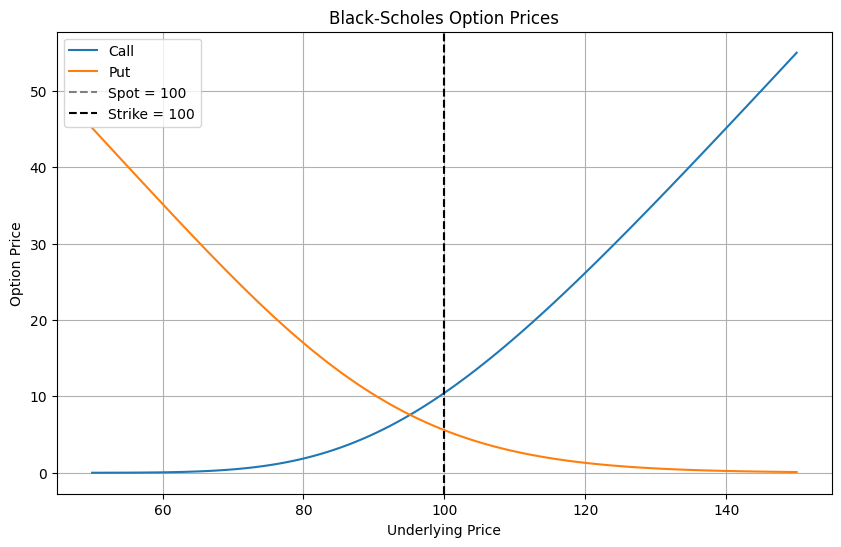

In [4]:
S_range = np.linspace(50, 150, 100)
prices_call = [BlackScholes(S, K, T, r, sigma).price('call') for S in S_range]
prices_put = [BlackScholes(S, K, T, r, sigma).price('put') for S in S_range]

plt.figure(figsize=(10, 6))
plt.plot(S_range, prices_call, label='Call')
plt.plot(S_range, prices_put, label='Put')
plt.axvline(x=S0, color='gray', linestyle='--', label=f'Spot = {S0}')
plt.axvline(x=K, color='black', linestyle='--', label=f'Strike = {K}')
plt.xlabel('Underlying Price')
plt.ylabel('Option Price')
plt.title('Black-Scholes Option Prices')
plt.legend()
plt.grid(True)
plt.show()

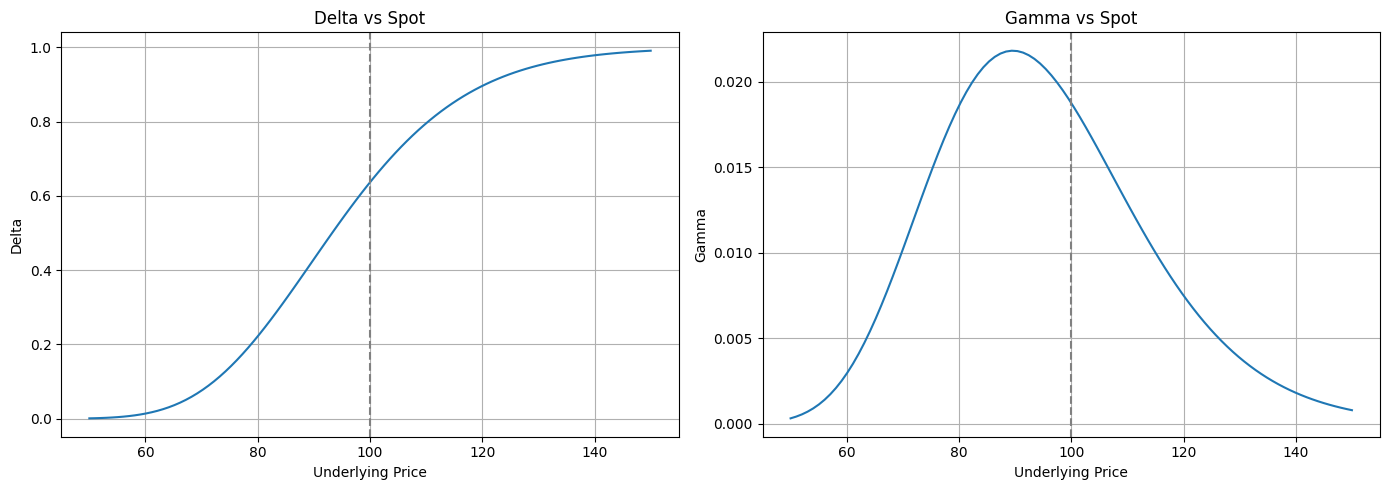

In [5]:
delta_call = [BlackScholes(S, K, T, r, sigma).delta('call') for S in S_range]
gamma_vals = [BlackScholes(S, K, T, r, sigma).gamma() for S in S_range]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(S_range, delta_call)
ax1.axvline(x=S0, color='gray', linestyle='--')
ax1.set_xlabel('Underlying Price')
ax1.set_ylabel('Delta')
ax1.set_title('Delta vs Spot')
ax1.grid(True)

ax2.plot(S_range, gamma_vals)
ax2.axvline(x=S0, color='gray', linestyle='--')
ax2.set_xlabel('Underlying Price')
ax2.set_ylabel('Gamma')
ax2.set_title('Gamma vs Spot')
ax2.grid(True)

plt.tight_layout()
plt.show()